# Dense Linear Probe: Pixel-Level Cardiac Segmentation with CineMA on ACDC

This notebook trains a **dense linear probe** for semantic segmentation of cardiac MRI slices
using the **pretrained CineMA backbone** (`mathpluscode/CineMA`) on the
ACDC dataset (100 train / 50 test patients).

**Architecture**: Frozen CineMA backbone → cached 2D slice features (768-dim) →
Dropout2d → BatchNorm2d → per-pixel 1×1 Conv2d → bilinear upsample (4 classes: BG, RV, MYO, LV).

This uses the same `DenseLinearProbe` head as the DINOv3 notebook
(`acdc_dino_dense_linear_probe_segmentation.ipynb`), which matches the official DINOv3
`LinearHead` architecture. Features are classified at **patch resolution** (12×12),
then upsampled to full resolution.

**What the notebook does**:
1. Loads the ACDC dataset and splits training patients into train/val (stratified by pathology)
2. Caches frozen CineMA SAX features to disk (single layer, 768-dim)
3. Trains a dense linear probe on the cached features using **class-weighted Dice + CrossEntropy** loss
4. Evaluates per-class and per-patient Dice scores on the held-out test set
5. Visualises pixel-level predictions vs ground truth
6. Saves the trained probe head

**Key difference from DINOv3 linear probe**: CineMA outputs a single feature layer (768-dim)
rather than multiple intermediate layers, so there is no layer selection to configure.

## 1. Imports and Configuration

In [1]:
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from cinema import CineMA
from cinema.segmentation.dataset import EndDiastoleEndSystoleDataset
from monai.transforms import ScaleIntensityd
from torch.utils.data import DataLoader
from tqdm import tqdm

from heartfm_evals.dense_linear_probe import (
    CLASS_COLORS,
    CLASS_NAMES,
    DiceLoss,
    IMAGE_SIZE,
    NUM_CLASSES,
    CachedFeatureDataset,
    DenseLinearProbe,
    dice_score,
    evaluate,
    macro_dice,
    overlay_labels,
    train_one_epoch,
)

In [2]:
# -- Paths --
ACDC_DATA_DIR = Path("/Users/lbokeria/projects/health_gc/data/heartfm/processed/acdc")

# -- CineMA loading --
HF_CACHE_DIR = Path("../../model_weights/hf")
AUTO_DOWNLOAD = True

# -- Cache (reuses features from the CineMA conv decoder notebook) --
CACHE_NAME = "cinema_pretrained"
CACHE_DIR = Path(f"../../feature_cache/{CACHE_NAME}")
SAX_TARGET_DEPTH = 16  # CineMA pretrained SAX depth
EMBED_DIM = 768  # CineMA SAX embed dim

# -- Training --
BATCH_SIZE = 16
LR = 1e-3
WEIGHT_DECAY = 1e-3
DROPOUT = 0.1
N_EPOCHS = 20
PATIENCE = 10

# -- Device --
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

HF_CACHE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Using device: {DEVICE}")
print(f"CineMA source: mathpluscode/CineMA (auto_download={AUTO_DOWNLOAD})")
print(f"Feature dim: {EMBED_DIM}, cache: {CACHE_DIR}")

Using device: mps
CineMA source: mathpluscode/CineMA (auto_download=True)
Feature dim: 768, cache: ../../feature_cache/cinema_pretrained


## 2. Load ACDC Data

In [3]:
train_meta_df = pd.read_csv(ACDC_DATA_DIR / "train_metadata.csv")
test_meta_df = pd.read_csv(ACDC_DATA_DIR / "test_metadata.csv")

print(f"Full training set: {len(train_meta_df)} patients")
print(f"Full test set:     {len(test_meta_df)} patients")
if "pathology" in train_meta_df.columns:
    print(f"\nPathology distribution (train):\n{train_meta_df['pathology'].value_counts().to_string()}")

Full training set: 100 patients
Full test set:     50 patients

Pathology distribution (train):
pathology
DCM     20
HCM     20
MINF    20
NOR     20
RV      20


### Train / Validation Split

Stratified by pathology: 2 patients per group held out for validation
(10 val / 90 train), following the CineMA convention.

In [4]:
if "pathology" in train_meta_df.columns:
    val_pids = (
        train_meta_df.groupby("pathology")
        .sample(n=2, random_state=0)["pid"]
        .tolist()
    )
else:
    val_pids = train_meta_df.sample(frac=0.1, random_state=0)["pid"].tolist()

train_split_df = train_meta_df[~train_meta_df["pid"].isin(val_pids)].reset_index(drop=True)
val_split_df = train_meta_df[train_meta_df["pid"].isin(val_pids)].reset_index(drop=True)

print(f"Train split: {len(train_split_df)} patients")
print(f"Val split:   {len(val_split_df)} patients")
print(f"Test set:    {len(test_meta_df)} patients")
print(f"\nVal patient IDs: {val_pids}")

Train split: 90 patients
Val split:   10 patients
Test set:    50 patients

Val patient IDs: ['patient019', 'patient002', 'patient032', 'patient022', 'patient056', 'patient054', 'patient079', 'patient061', 'patient088', 'patient082']


In [5]:
transform = ScaleIntensityd(keys="sax_image", factor=1 / 255, channel_wise=False)

train_cinema = EndDiastoleEndSystoleDataset(
    data_dir=ACDC_DATA_DIR / "train",
    meta_df=train_split_df,
    views="sax",
    transform=transform,
)

val_cinema = EndDiastoleEndSystoleDataset(
    data_dir=ACDC_DATA_DIR / "train",
    meta_df=val_split_df,
    views="sax",
    transform=transform,
)

test_cinema = EndDiastoleEndSystoleDataset(
    data_dir=ACDC_DATA_DIR / "test",
    meta_df=test_meta_df,
    views="sax",
    transform=transform,
)

print(f"Train CineMA dataset: {len(train_cinema)} samples")
print(f"Val CineMA dataset:   {len(val_cinema)} samples")
print(f"Test CineMA dataset:  {len(test_cinema)} samples")

Train CineMA dataset: 180 samples
Val CineMA dataset:   20 samples
Test CineMA dataset:  100 samples


## 3. Load Pretrained CineMA and Cache Slice Features

Since the backbone is **frozen**, we pre-extract features once and cache to disk.
If features are already cached (from the conv decoder notebook), they are reused.

In [6]:
backbone = CineMA.from_pretrained(
    cache_dir=str(HF_CACHE_DIR),
    local_files_only=not AUTO_DOWNLOAD,
)
backbone.eval().to(DEVICE)
for p in backbone.parameters():
    p.requires_grad = False

grid_size = backbone.enc_down_dict["sax"].patch_embed.grid_size
embed_dim = backbone.enc_down_dict["sax"].patch_embed.proj.out_features
print(f"Loaded CineMA pretrained backbone")
print(f"SAX token grid: {grid_size}, embed_dim: {embed_dim}")

MainThread-11861 | 2026-04-01 13:01:44-cinema.mae.mae-from_pretrained:623 | [INFO] Cached model weights to ../../model_weights/hf/models--mathpluscode--CineMA/snapshots/b1251ee50423bceeca84c080782fc3bc7756dea6/pretrained/cinema.safetensors.
MainThread-11861 | 2026-04-01 13:01:44-cinema.mae.mae-from_pretrained:635 | [INFO] Cached model config to ../../model_weights/hf/models--mathpluscode--CineMA/snapshots/b1251ee50423bceeca84c080782fc3bc7756dea6/pretrained/config.yaml.
MainThread-11861 | 2026-04-01 13:01:45-cinema.mae.mae-from_pretrained:641 | [INFO] Loaded pretrained weights.
Loaded CineMA pretrained backbone
SAX token grid: (12, 12, 16), embed_dim: 768


In [7]:
@torch.inference_mode()
def extract_cinema_sax_feature_volume(backbone, sax_volume, device, target_depth=SAX_TARGET_DEPTH):
    # sax_volume: (1, H, W, z) in [0,1]
    vol = sax_volume
    z = int(vol.shape[-1])
    if z > target_depth:
        vol = vol[..., :target_depth]
        z = target_depth
    if z < target_depth:
        vol = F.pad(vol, (0, target_depth - z), mode="constant", value=0.0)

    batch = {"sax": vol.unsqueeze(0).to(device=device, dtype=torch.float32)}  # (1,1,H,W,Z)
    tokens = backbone.feature_forward(batch)["sax"]  # (1, n_tokens, C)

    b, n_tokens, c = tokens.shape
    gx, gy, gz = backbone.enc_down_dict["sax"].patch_embed.grid_size
    if n_tokens != gx * gy * gz:
        raise RuntimeError(f"Unexpected token count: {n_tokens} vs grid {gx}x{gy}x{gz}")

    feat_vol = tokens.reshape(b, gx, gy, gz, c).permute(0, 4, 1, 2, 3).contiguous()  # (1,C,gx,gy,gz)
    return feat_vol.squeeze(0).cpu(), z


def cache_cinema_features(backbone, cinema_dataset, cache_dir, device):
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    manifest = []

    for sample_idx in tqdm(range(len(cinema_dataset)), desc="Caching CineMA features"):
        sample = cinema_dataset[sample_idx]
        image_3d = sample["sax_image"]  # (1, H, W, z)
        label_3d = sample["sax_label"]  # (1, H, W, z)
        n_slices = int(sample["n_slices"])
        pid = sample["pid"]
        is_ed = sample["is_ed"]
        frame = "ed" if is_ed else "es"

        feat_vol, used_depth = extract_cinema_sax_feature_volume(backbone, image_3d, device)
        gz = feat_vol.shape[-1]

        for z_idx in range(n_slices):
            fname = f"{pid}_{frame}_z{z_idx:02d}.pt"
            fpath = cache_dir / fname

            if fpath.exists():
                manifest.append({"path": fpath, "pid": pid, "is_ed": is_ed, "z_idx": z_idx})
                continue

            # Map original slice index to feature-volume depth index
            src_z = min(z_idx, max(used_depth - 1, 0))
            feat_z = int(round(src_z * (gz - 1) / max(used_depth - 1, 1)))

            feats_2d = feat_vol[..., feat_z]  # (C, gx, gy)
            label_2d = label_3d[0, :, :, z_idx]

            torch.save({"features": feats_2d, "label": label_2d.long()}, fpath)
            manifest.append({"path": fpath, "pid": pid, "is_ed": is_ed, "z_idx": z_idx})

    return manifest

In [8]:
print("Caching training features...")
train_manifest = cache_cinema_features(backbone, train_cinema, CACHE_DIR / "train", DEVICE)

print("\nCaching validation features...")
val_manifest = cache_cinema_features(backbone, val_cinema, CACHE_DIR / "val", DEVICE)

print("\nCaching test features...")
test_manifest = cache_cinema_features(backbone, test_cinema, CACHE_DIR / "test", DEVICE)

print(f"\nCached: {len(train_manifest)} train, {len(val_manifest)} val, {len(test_manifest)} test slices")

Caching training features...


Caching CineMA features: 100%|██████████| 180/180 [02:23<00:00,  1.25it/s]



Caching validation features...


Caching CineMA features: 100%|██████████| 20/20 [00:15<00:00,  1.26it/s]



Caching test features...


Caching CineMA features: 100%|██████████| 100/100 [01:19<00:00,  1.26it/s]


Cached: 1534 train, 178 val, 916 test slices


In [9]:
# Verify cached feature shapes
sample = torch.load(train_manifest[0]["path"], weights_only=True)
print(f"Feature shape: {sample['features'].shape}")  # expect (768, 12, 12)
print(f"Label shape:   {sample['label'].shape}")      # expect (192, 192)

assert sample["features"].shape[0] == EMBED_DIM, (
    f"Expected {EMBED_DIM} channels, got {sample['features'].shape[0]}"
)
print("Shape check passed!")

Feature shape: torch.Size([768, 12, 12])
Label shape:   torch.Size([192, 192])
Shape check passed!


## 4. Create DataLoaders

In [10]:
train_ds = CachedFeatureDataset(train_manifest)
val_ds = CachedFeatureDataset(val_manifest)
test_ds = CachedFeatureDataset(test_manifest)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_ds)} slices, {len(train_loader)} batches")
print(f"Val:   {len(val_ds)} slices, {len(val_loader)} batches")
print(f"Test:  {len(test_ds)} slices, {len(test_loader)} batches")

Train: 1534 slices, 96 batches
Val:   178 slices, 12 batches
Test:  916 slices, 58 batches


## 5. Define Model, Loss, Optimizer

In [11]:
class WeightedCombinedLoss(nn.Module):
    def __init__(self, ce_weight_tensor, ce_weight=1.0, dice_weight=1.0):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=ce_weight_tensor)
        self.dice = DiceLoss()
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        return self.ce_weight * self.ce(logits, targets.long()) + self.dice_weight * self.dice(logits, targets)

In [12]:
probe = DenseLinearProbe(
    embed_dim=EMBED_DIM,
    num_classes=NUM_CLASSES,
    layer_indices=(0,),  # CineMA: single layer, no selection needed
    dropout=DROPOUT,
).to(DEVICE)

# Compute class weights from training labels
class_counts = torch.zeros(NUM_CLASSES, dtype=torch.long)
for entry in train_manifest:
    y = torch.load(entry["path"], weights_only=True)["label"]
    class_counts += torch.bincount(y.long().reshape(-1), minlength=NUM_CLASSES)

class_weights = class_counts.sum().float() / (NUM_CLASSES * class_counts.clamp_min(1).float())
class_weights[0] = class_weights[0] * 0.5  # downweight background
class_weights = class_weights / class_weights.mean()

criterion = WeightedCombinedLoss(class_weights.to(DEVICE), ce_weight=1.0, dice_weight=1.0)
optimizer = torch.optim.AdamW(probe.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

n_params = sum(p.numel() for p in probe.parameters() if p.requires_grad)
print(f"Dense linear probe: {n_params:,} trainable parameters (includes BN + Conv)")
print(f"Class weights (BG/RV/MYO/LV): {class_weights.tolist()}")
print(f"Loss: weighted CE + Dice")
print(f"Optimizer: AdamW (lr={LR}, wd={WEIGHT_DECAY})")
print(f"Scheduler: CosineAnnealing (T_max={N_EPOCHS})")

Dense linear probe: 4,612 trainable parameters (includes BN + Conv)
Class weights (BG/RV/MYO/LV): [0.03057108074426651, 1.3994539976119995, 1.2823073863983154, 1.2876677513122559]
Loss: weighted CE + Dice
Optimizer: AdamW (lr=0.001, wd=0.001)
Scheduler: CosineAnnealing (T_max=20)


## 6. Training Loop

In [13]:
best_val_dice = 0.0
best_epoch = 0
epochs_no_improve = 0
history = {"train_loss": [], "val_macro_dice": [], "lr": []}

for epoch in range(1, N_EPOCHS + 1):
    # Train
    train_loss = train_one_epoch(probe, train_loader, criterion, optimizer, DEVICE)
    scheduler.step()

    # Validate
    val_metrics = evaluate(probe, val_loader, DEVICE)
    val_dice = val_metrics["macro_dice"]

    # Record
    history["train_loss"].append(train_loss)
    history["val_macro_dice"].append(val_dice)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    # Print every 5 epochs or on improvement
    improved = val_dice > best_val_dice
    if epoch % 5 == 0 or epoch == 1 or improved:
        tag = " *" if improved else ""
        print(
            f"Epoch {epoch:3d}/{N_EPOCHS} | "
            f"loss={train_loss:.4f} | "
            f"val Dice={val_dice:.4f} | "
            f"lr={optimizer.param_groups[0]['lr']:.2e}{tag}"
        )

    # Early stopping
    if improved:
        best_val_dice = val_dice
        best_epoch = epoch
        epochs_no_improve = 0
        best_state = {k: v.cpu().clone() for k, v in probe.state_dict().items()}
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}. Best val Dice={best_val_dice:.4f} at epoch {best_epoch}.")
            break

# Restore best model
probe.load_state_dict(best_state)
print(f"\nRestored best model from epoch {best_epoch} (val Dice={best_val_dice:.4f})")

Epoch   1/20 | loss=1.3827 | val Dice=0.5646 | lr=9.94e-04 *
Epoch   2/20 | loss=0.9152 | val Dice=0.6436 | lr=9.76e-04 *
Epoch   3/20 | loss=0.8310 | val Dice=0.6558 | lr=9.46e-04 *
Epoch   4/20 | loss=0.8018 | val Dice=0.6659 | lr=9.05e-04 *
Epoch   5/20 | loss=0.7812 | val Dice=0.6757 | lr=8.54e-04 *
Epoch   9/20 | loss=0.7419 | val Dice=0.6788 | lr=5.78e-04 *
Epoch  10/20 | loss=0.7379 | val Dice=0.6752 | lr=5.00e-04
Epoch  11/20 | loss=0.7340 | val Dice=0.6835 | lr=4.22e-04 *
Epoch  13/20 | loss=0.7257 | val Dice=0.6919 | lr=2.73e-04 *
Epoch  15/20 | loss=0.7315 | val Dice=0.6877 | lr=1.46e-04
Epoch  20/20 | loss=0.7203 | val Dice=0.6885 | lr=0.00e+00

Restored best model from epoch 13 (val Dice=0.6919)


### Training Curves

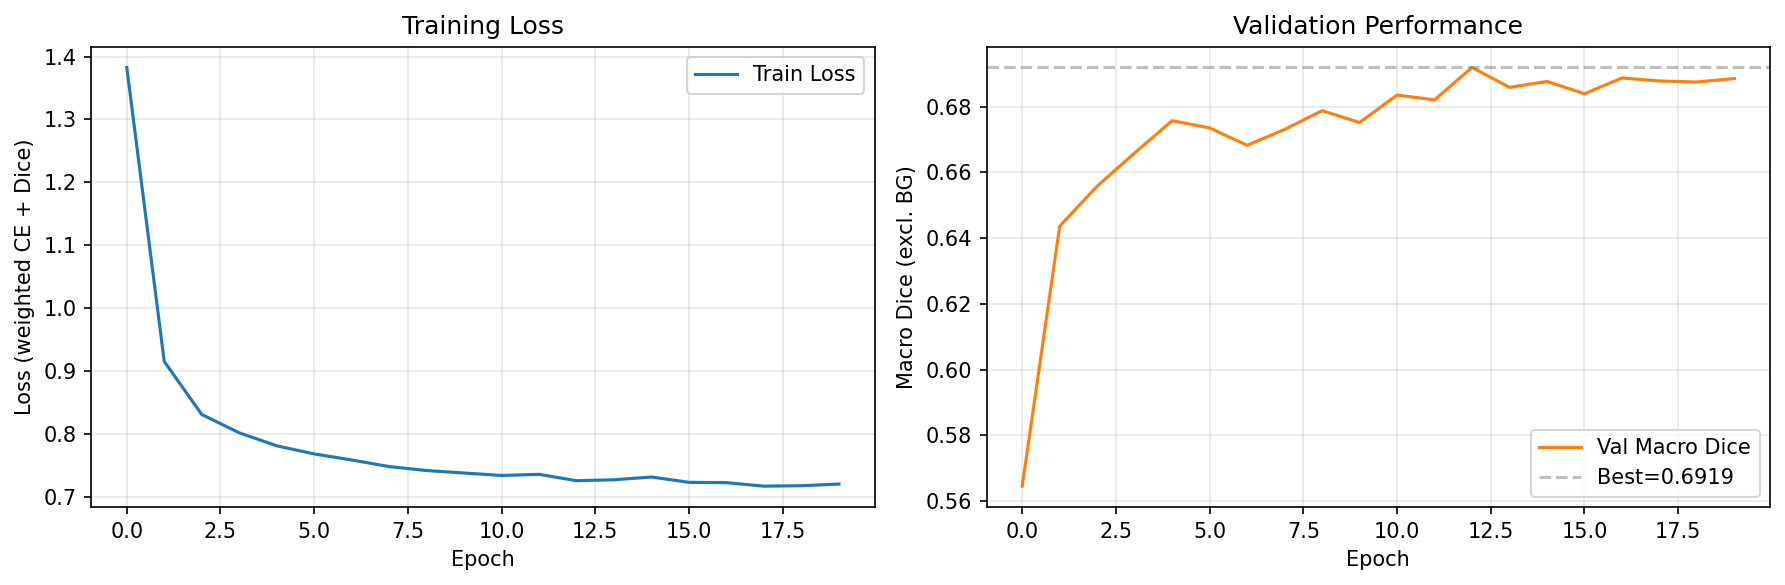

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), dpi=150)

ax1.plot(history["train_loss"], label="Train Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss (weighted CE + Dice)")
ax1.set_title("Training Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history["val_macro_dice"], label="Val Macro Dice", color="tab:orange")
ax2.axhline(best_val_dice, ls="--", color="gray", alpha=0.5, label=f"Best={best_val_dice:.4f}")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Macro Dice (excl. BG)")
ax2.set_title("Validation Performance")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Test Set Evaluation

In [15]:
test_metrics = evaluate(probe, test_loader, DEVICE)

print("Per-class Dice scores (test set):")
for name, d in test_metrics["per_class_dice"].items():
    print(f"  {name:>3s}: {d:.4f}")
print(f"\nMacro Dice (excl. BG): {test_metrics['macro_dice']:.4f}")

Per-class Dice scores (test set):
   BG: 0.9652
   RV: 0.6825
  MYO: 0.5771
   LV: 0.8096

Macro Dice (excl. BG): 0.6897


### Per-Patient Dice Scores

In [16]:
patient_dices = []

probe.eval()
with torch.inference_mode():
    for i, entry in enumerate(test_manifest):
        data = torch.load(entry["path"], weights_only=True)
        feats = data["features"].unsqueeze(0).to(DEVICE)
        label = data["label"].numpy()

        logits = probe(feats)
        pred = logits.argmax(dim=1).squeeze(0).cpu().numpy()

        patient_dices.append({
            "pid": entry["pid"],
            "z_idx": entry["z_idx"],
            "macro_dice": macro_dice(pred, label),
            **{CLASS_NAMES[c]: dice_score(pred, label, c) for c in range(NUM_CLASSES)},
        })

dice_df = pd.DataFrame(patient_dices)
patient_summary = dice_df.groupby("pid")[["macro_dice", "RV", "MYO", "LV"]].mean()
print("Per-patient mean Macro Dice (test set):")
print(patient_summary.round(4).to_string())
print(f"\nOverall mean \u00b1 std: {patient_summary['macro_dice'].mean():.4f} \u00b1 {patient_summary['macro_dice'].std():.4f}")

Per-patient mean Macro Dice (test set):
            macro_dice      RV     MYO      LV
pid                                           
patient101      0.5309  0.4315  0.4692  0.6921
patient102      0.4824  0.4810  0.4401  0.5261
patient103      0.5275  0.2488  0.6271  0.7065
patient104      0.5195  0.3781  0.6425  0.5380
patient105      0.4394  0.3806  0.5006  0.4370
patient106      0.6899  0.8179  0.4945  0.7574
patient107      0.4309  0.3666  0.3197  0.6063
patient108      0.5034  0.4496  0.5515  0.5092
patient109      0.6458  0.6974  0.5301  0.7097
patient110      0.5714  0.5517  0.5273  0.6351
patient111      0.5607  0.4544  0.6887  0.5389
patient112      0.5686  0.4562  0.5352  0.7145
patient113      0.6471  0.5511  0.5702  0.8200
patient114      0.5509  0.3369  0.6887  0.6270
patient115      0.5730  0.4245  0.5594  0.7353
patient116      0.4828  0.3751  0.5332  0.5401
patient117      0.6703  0.6111  0.5820  0.8179
patient118      0.5828  0.4845  0.5805  0.6834
patient119      0.55

## 8. Visualization — Pixel-Level Predictions

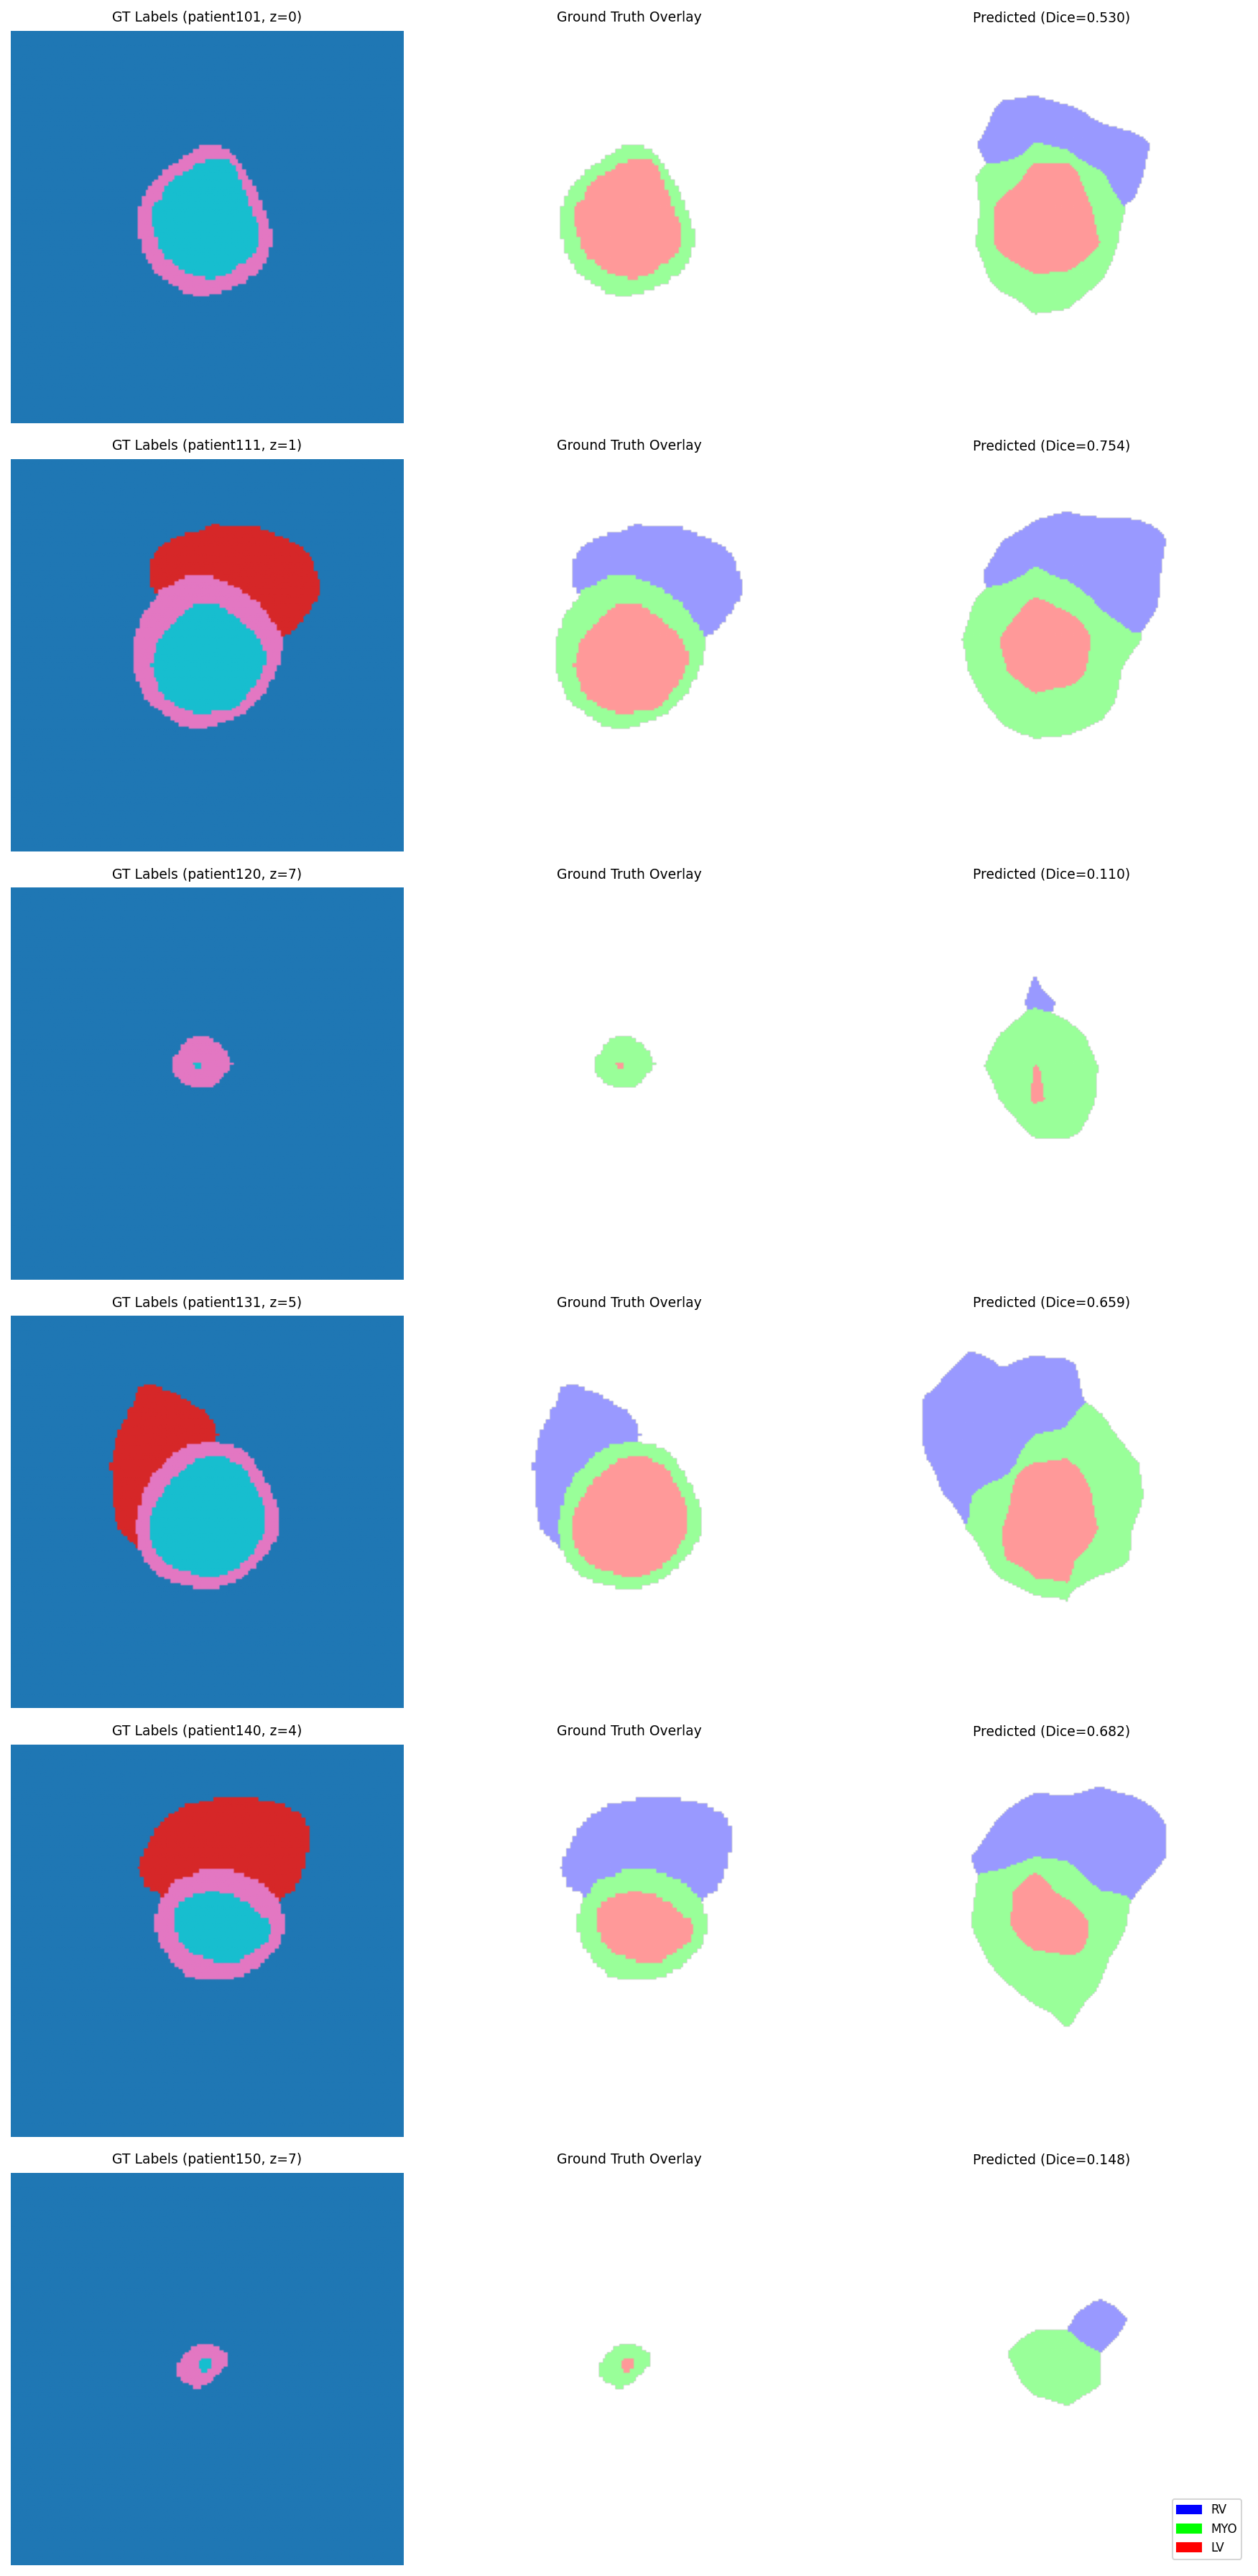

In [17]:
# Pick 6 evenly-spaced test slices for visualization
n_show = min(6, len(test_manifest))
show_indices = np.linspace(0, len(test_manifest) - 1, n_show, dtype=int)

fig, axes = plt.subplots(n_show, 3, figsize=(12, 4 * n_show), dpi=150)
if n_show == 1:
    axes = axes[np.newaxis, :]

probe.eval()
with torch.inference_mode():
    for row, idx in enumerate(show_indices):
        entry = test_manifest[idx]
        data = torch.load(entry["path"], weights_only=True)
        feats = data["features"].unsqueeze(0).to(DEVICE)
        label = data["label"].numpy()

        logits = probe(feats)
        pred = logits.argmax(dim=1).squeeze(0).cpu().numpy()

        gt_overlay = overlay_labels(label, IMAGE_SIZE, IMAGE_SIZE)
        pred_overlay = overlay_labels(pred, IMAGE_SIZE, IMAGE_SIZE)

        axes[row, 0].imshow(label, cmap="tab10", vmin=0, vmax=3)
        axes[row, 0].set_title(f"GT Labels ({entry['pid']}, z={entry['z_idx']})", fontsize=9)
        axes[row, 0].axis("off")

        axes[row, 1].imshow(gt_overlay)
        axes[row, 1].set_title("Ground Truth Overlay", fontsize=9)
        axes[row, 1].axis("off")

        axes[row, 2].imshow(pred_overlay)
        axes[row, 2].set_title(f"Predicted (Dice={macro_dice(pred, label):.3f})", fontsize=9)
        axes[row, 2].axis("off")

legend_patches = [
    mpatches.Patch(color=CLASS_COLORS[c][:3] + (1.0,), label=CLASS_NAMES[c])
    for c in range(1, NUM_CLASSES)
]
axes[-1, 2].legend(handles=legend_patches, loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 9. Save Model

In [18]:
save_path = Path("../dense_linear_probe_cinema_pretrained.pt")
torch.save(
    {
        "model_state_dict": probe.state_dict(),
        "backbone": "mathpluscode/CineMA",
        "embed_dim": EMBED_DIM,
        "num_classes": NUM_CLASSES,
        "best_epoch": best_epoch,
        "best_val_dice": best_val_dice,
        "test_metrics": test_metrics,
        "val_pids": val_pids,
    },
    save_path,
)
print(f"Model saved to {save_path}")

Model saved to ../dense_linear_probe_cinema_pretrained.pt
